**Configuración de Spark**

In [33]:
!apt-get install openjdk-11-jdk-headless -qq > /dev/null
!wget -q http://apache.osuosl.org/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz
!tar xf spark-3.5.0-bin-hadoop3.tgz
!pip install -q findspark pyspark

import os, findspark
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

spark = SparkSession.builder.appName("CorrelacionClusteringAnalysis").getOrCreate()


tar: spark-3.5.0-bin-hadoop3.tgz: Cannot open: No such file or directory
tar: Error is not recoverable: exiting now


**Cargar el dataset y preparar datos**

In [34]:
# Cargar parquet (subcarpeta interna como en tu caso)
df = spark.read.parquet("/content/merge_pyspark/merge_pyspark")
df.createOrReplaceTempView("customer_transactions")

# Dejar solo lo necesario
df_clean = spark.sql("""
    SELECT
        customer_id,
        Fecha,
        price
    FROM customer_transactions
""")
df_clean.createOrReplaceTempView("clean_transactions")


**Calcular R, F, M**

In [35]:
# Frecuencia
frecuency = spark.sql("""
SELECT customer_id, COUNT(1) AS Frequency
FROM clean_transactions
GROUP BY customer_id
""")
frecuency.createOrReplaceTempView("frecuency")

# Monto (Monetary)
amount = spark.sql("""
SELECT customer_id, SUM(price) AS Sold
FROM clean_transactions
GROUP BY customer_id
""")
amount.createOrReplaceTempView("amount")

# Última compra (Recency)
lastbuy = spark.sql("""
WITH ranked_purchases AS (
    SELECT customer_id,
           Fecha,
           LAG(Fecha) OVER (PARTITION BY customer_id ORDER BY Fecha) AS prev,
           ROW_NUMBER() OVER (PARTITION BY customer_id ORDER BY Fecha DESC) AS rnum
    FROM clean_transactions
)
SELECT customer_id, Fecha, prev, DATEDIFF(Fecha, prev) AS Days
FROM ranked_purchases
WHERE rnum = 1 AND prev IS NOT NULL
""")
lastbuy.createOrReplaceTempView("lastbuy")

# Dataset consolidado
retail = spark.sql("""
SELECT f.customer_id,
       f.Frequency,
       a.Sold,
       l.Days
FROM frecuency f
JOIN amount a ON f.customer_id = a.customer_id
JOIN lastbuy l ON f.customer_id = l.customer_id
""")
retail.createOrReplaceTempView("hym")


**Crear percentiles y scores RFM**

In [36]:
df = spark.sql("""
    SELECT customer_id,
           CAST(Frequency AS INT) AS Frequency,
           CAST(Sold AS FLOAT) AS Sold,
           CAST(Days AS INT) AS Days
    FROM hym
""")

# Percentiles
w_recency = Window.orderBy(F.col("Days").asc())       # menor Days = más reciente
w_frequency = Window.orderBy(F.col("Frequency").asc()) # mayor frecuencia = mejor

df_rfm = df \
    .withColumn("recency_percentile", F.percent_rank().over(w_recency)) \
    .withColumn("frequency_percentile", F.percent_rank().over(w_frequency))

# Scores
df_rfm = df_rfm \
    .withColumn("recency_score",
        F.when(F.col("recency_percentile") <= 0.2, 5)
         .when(F.col("recency_percentile") <= 0.4, 4)
         .when(F.col("recency_percentile") <= 0.6, 3)
         .when(F.col("recency_percentile") <= 0.8, 2)
         .otherwise(1)
    ) \
    .withColumn("frequency_score",
        F.when(F.col("frequency_percentile") <= 0.2, 1)
         .when(F.col("frequency_percentile") <= 0.4, 2)
         .when(F.col("frequency_percentile") <= 0.6, 3)
         .when(F.col("frequency_percentile") <= 0.8, 4)
         .otherwise(5)
    )

# Score RFM
df_rfm = df_rfm.withColumn(
    "RFM_score",
    F.concat_ws("", F.col("recency_score").cast("string"),
                   F.col("frequency_score").cast("string"))
)


**Mapear segmentos**

In [37]:
# Diccionario de segmentos (del PDF)
seg_map = {
    r'[1-2][1-2]': 'hibernating',
    r'[1-2][3-4]': 'at_risk',
    r'[1-2]5': 'cant_loose',
    r'3[1-2]': 'about_to_sleep',
    r'33': 'need_attention',
    r'[3-4][4-5]': 'loyal_customers',
    r'41': 'promising',
    r'51': 'new_customers',
    r'[4-5][2-3]': 'potential_loyalists',
    r'5[4-5]': 'champions'
}

segment_column = F.lit(None)
for pattern, label in seg_map.items():
    segment_column = F.when(F.col("RFM_score").rlike(pattern), label).otherwise(segment_column)

df_rfm = df_rfm.withColumn("segment", segment_column)

df_final = df_rfm.select("Days", "Frequency", "Sold", "segment")


**Gráfico de distribución de segmentos**

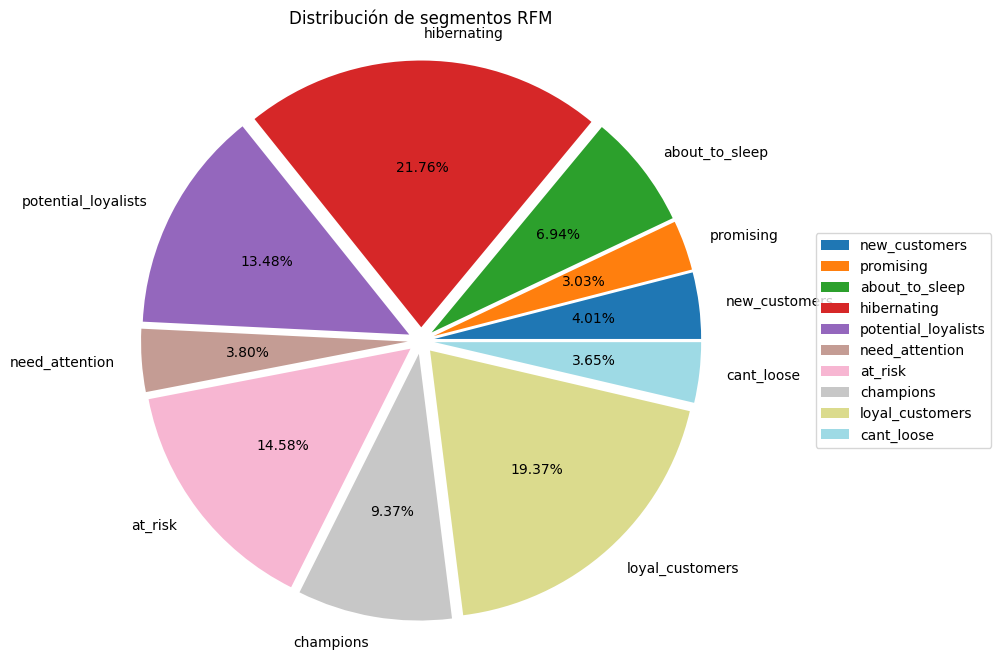

In [38]:
import matplotlib.pyplot as plt

# Contar clientes por segmento
segments = df_final.groupBy("segment").count().toPandas()
segments = segments.set_index("segment")["count"]

# Gráfico de pastel
plt.figure(figsize=(10, 8))
explode = [0.05] * len(segments)   # resaltar todas las porciones

segments.plot(
    kind='pie',
    autopct='%1.2f%%',
    colormap='tab20',
    explode=explode,
    ylabel=''
)

plt.axis('equal')
plt.legend(labels=segments.index, loc="center left", bbox_to_anchor=(1, 0.5), ncol=1)
plt.title("Distribución de segmentos RFM")
plt.show()


**Reporte tabular de métricas por segmento**

In [39]:
# Resumen de métricas por segmento
segment_report = df_final.groupBy("segment").agg(
    F.mean("Days").alias("Avg_Recency"),
    F.mean("Frequency").alias("Avg_Frequency"),
    F.mean("Sold").alias("Avg_Sold"),
    F.count("*").alias("Num_Customers")
).orderBy("Num_Customers", ascending=False)

segment_report.show(truncate=False)


+-------------------+------------------+------------------+-------------------+-------------+
|segment            |Avg_Recency       |Avg_Frequency     |Avg_Sold           |Num_Customers|
+-------------------+------------------+------------------+-------------------+-------------+
|hibernating        |230.61552866609046|7.578975799481418 |0.2119974729226225 |27768        |
|loyal_customers    |32.92976493911073 |68.9585305660072  |1.9141186792188687 |24717        |
|at_risk            |178.48345153664303|26.00762948635289 |0.7052981999166136 |18612        |
|potential_loyalists|11.961129510196967|15.267387136133868|0.4066583874675604 |17211        |
|champions          |4.331047172967548 |81.05260956841754 |2.2990546687545086 |11956        |
|about_to_sleep     |49.62069743821239 |8.008689764134974 |0.2183034359479037 |8861         |
|new_customers      |4.030835284933645 |4.554254488680718 |0.14218418144004435|5124         |
|need_attention     |49.32276004119464 |19.544387229660146|0